In [1]:
"""
Notebook 05: Backtest Engine
========================================
目标：
1. 实现严格的回测引擎（不是 Day 3 的简化预演）
2. 加入交易成本（commission + slippage）
3. 月度再平衡的正确实现
4. 计算完整风险指标（Sharpe, Sortino, Max DD, Calmar）
5. 与 SPY 严格对比
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = "/Users/victor/quant-research-2026"

# 加载数据
prices = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data/prices_panel.csv'),
    index_col=0, parse_dates=True
)
returns = pd.read_csv(
    os.path.join(PROJECT_ROOT, 'data/returns_panel.csv'),
    index_col=0, parse_dates=True
)

# 策略参数（可调整）
LOOKBACK_MONTHS = 12      # 动量回看期
SKIP_MONTHS = 1           # 跳过最近 1 月（避免短期反转）
N_HOLDINGS = 5            # 持仓数
REBALANCE_FREQ = 'M'      # 月末再平衡
COMMISSION = 0.001        # 单边手续费 0.1%
SLIPPAGE = 0.0005         # 滑点 0.05%
INITIAL_CAPITAL = 100000  # 起始资金

print(f"数据加载完成")
print(f"  价格面板: {prices.shape}")
print(f"  时间范围: {prices.index[0].strftime('%Y-%m-%d')} 至 {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"  股票数量: {len(prices.columns)}")
print(f"\n策略配置:")
print(f"  Lookback: {LOOKBACK_MONTHS} 月")
print(f"  Skip: {SKIP_MONTHS} 月")
print(f"  Top N: {N_HOLDINGS}")
print(f"  Commission: {COMMISSION*100:.2f}% per side")
print(f"  Slippage: {SLIPPAGE*100:.3f}% per trade")
print(f"  Initial capital: ${INITIAL_CAPITAL:,}")

数据加载完成
  价格面板: (1588, 31)
  时间范围: 2020-01-02 至 2026-04-28
  股票数量: 31

策略配置:
  Lookback: 12 月
  Skip: 1 月
  Top N: 5
  Commission: 0.10% per side
  Slippage: 0.050% per trade
  Initial capital: $100,000


In [3]:
monthly_prices = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change()

def compute_momentum(monthly_prices, lookback=12, skip=1):
    end_price = monthly_prices.shift(skip)
    start_price = monthly_prices.shift(skip + lookback)
    return end_price / start_price - 1

momentum = compute_momentum(monthly_prices, LOOKBACK_MONTHS, SKIP_MONTHS)
ranks = momentum.rank(axis=1, ascending = False)

ranks_no_spy = ranks.drop(columns = ['SPY'], errors = 'ignore')

positions = pd.DataFrame(0.0, index=ranks_no_spy.index, columns = ranks_no_spy.columns)

for date in ranks_no_spy.index:
    if pd.isna(ranks_no_spy.loc[date]).all():
        continue
    top_n = ranks_no_spy.loc[date].nsmallest(N_HOLDINGS).index
    positions.loc[date, top_n] = 1.0 / N_HOLDINGS

print("=== 最近六个月持仓 ===")
print(positions.tail(6).loc[:, (positions.tail(6) > 0).any()])


=== 最近六个月持仓 ===
            GOOGL  NVDA  TSLA  AVGO  ORCL   GS  CAT   GE  JNJ
date                                                         
2025-11-30    0.2   0.0   0.2   0.2   0.2  0.0  0.0  0.2  0.0
2025-12-31    0.2   0.0   0.0   0.2   0.0  0.2  0.2  0.2  0.0
2026-01-31    0.2   0.0   0.0   0.2   0.0  0.2  0.2  0.2  0.0
2026-02-28    0.2   0.2   0.0   0.0   0.0  0.0  0.2  0.2  0.2
2026-03-31    0.2   0.0   0.0   0.2   0.0  0.0  0.2  0.2  0.2
2026-04-30    0.2   0.2   0.0   0.2   0.0  0.2  0.2  0.0  0.0


In [5]:
def run_backtest(
    monthly_prices,
    positions,
    initial_capital=100000,
    commission=0.001,
    slippage=0.0005
):
   """
    严格的月度再平衡回测引擎
    
    关键正确性细节：
    1. T 月末信号 → T+1 月初买入（避免前视偏差）
    2. 持仓到 T+1 月末
    3. 卖出旧持仓 + 买入新持仓 都有交易成本
    4. 现金部分不参与收益（保守假设）
    
    返回：
        portfolio_value: 每月底组合价值
        trades: 每月交易记录
   """
   aligned_positions = positions.shift(1)
   first_valid = aligned_positions.dropna(how = 'all').index[0]
   valid_dates = aligned_positions.loc[first_valid:].index
   
   portfolio_value = pd.Series(index = valid_dates, dtype = float)
   portfolio_value.iloc[0] = initial_capital 
   
   cash = initial_capital
   holdings = pd.Series(0.0, index=aligned_positions.columns)
   
   
   trades_log = []
   for i,date in enumerate(valid_dates):
    if i == 0:
        prev_value =  initial_capital 
    else:
        prev_date = valid_dates[i - 1]
        current_prices = monthly_prices.loc[date]
        holdings_value = (holdings * current_prices). sum()
        prev_value = cash + holdings_value

    target_weights = aligned_positions.loc[date].fillna(0)

    if (target_weights == 0).all():
            portfolio_value.loc[date] = prev_value
            continue


    current_prices = monthly_prices.loc[date]
    target_dollar_per_stock = prev_value * target_weights
    target_shares = (target_dollar_per_stock / current_prices).fillna(0)


    trade_shares = target_shares - holdings
    trade_dollar = (trade_shares.abs() * current_prices).sum()
    # 交易成本（commission + slippage）
    cost = trade_dollar * (commission + slippage)
        
        # 更新现金和持仓
    cash = prev_value - (target_shares * current_prices).sum() - cost
    holdings = target_shares
        
        # 这个月底的组合价值
    portfolio_value.loc[date] = cash + (holdings * current_prices).sum()
        
        # 记录交易
    trades_log.append({
            'date': date,
            'turnover': trade_dollar,
            'cost': cost,
            'cash': cash,
            'portfolio_value': portfolio_value.loc[date]
        })
    
    trades_df = pd.DataFrame(trades_log)
    
    return portfolio_value.dropna(), trades_df

# 运行回测
print("运行严格回测中...")
portfolio_value, trades = run_backtest(
    monthly_prices, positions,
    initial_capital=INITIAL_CAPITAL,
    commission=COMMISSION,
    slippage=SLIPPAGE
)

print(f"\n回测完成")
print(f"  起始资本: ${INITIAL_CAPITAL:,}")
print(f"  最终价值: ${portfolio_value.iloc[-1]:,.0f}")
print(f"  总收益: {(portfolio_value.iloc[-1] / INITIAL_CAPITAL - 1):.2%}")
print(f"  时间跨度: {portfolio_value.index[0].strftime('%Y-%m')} 到 {portfolio_value.index[-1].strftime('%Y-%m')}")
print(f"  月数: {len(portfolio_value)}")

print(f"\n=== 总交易成本统计 ===")
print(f"  总 turnover: ${trades['turnover'].sum():,.0f}")
print(f"  总成本: ${trades['cost'].sum():,.0f}")
print(f"  成本占初始资本: {trades['cost'].sum() / INITIAL_CAPITAL:.2%}")
print(f"\n  平均每月 turnover: ${trades['turnover'].mean():,.0f}")





运行严格回测中...

回测完成
  起始资本: $100,000
  最终价值: $99,850
  总收益: -0.15%
  时间跨度: 2020-02 到 2021-03
  月数: 14

=== 总交易成本统计 ===
  总 turnover: $100,000
  总成本: $150
  成本占初始资本: 0.15%

  平均每月 turnover: $100,000


In [6]:
# 诊断 positions 表的状态
print("=== positions 表诊断 ===\n")

print(f"positions 形状: {positions.shape}")
print(f"时间范围: {positions.index[0]} 至 {positions.index[-1]}")
print(f"总月数: {len(positions)}")

print(f"\n=== 每月持仓数（非零权重的股票数）===")
holdings_count = (positions > 0).sum(axis=1)
print(holdings_count.value_counts().sort_index())

print(f"\n=== 前 5 行（应该 NaN 或全 0）===")
print(positions.head(5))

print(f"\n=== 第 14-16 行（信号应该开始有效）===")
print(positions.iloc[13:16])

print(f"\n=== 倒数 5 行（应该有 5 只持仓）===")
print(positions.tail(5).loc[:, (positions.tail(5) > 0).any()])

print(f"\n=== 检查 NaN 数量 ===")
print(f"总 NaN: {positions.isna().sum().sum()}")
print(f"全 NaN 的月份数: {positions.isna().all(axis=1).sum()}")

=== positions 表诊断 ===

positions 形状: (76, 30)
时间范围: 2020-01-31 00:00:00 至 2026-04-30 00:00:00
总月数: 76

=== 每月持仓数（非零权重的股票数）===
0    13
5    63
Name: count, dtype: int64

=== 前 5 行（应该 NaN 或全 0）===
            AAPL  MSFT  GOOGL  AMZN  META  NVDA  TSLA  AVGO  ORCL  CRM  ...  \
date                                                                    ...   
2020-01-31   0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  ...   
2020-02-29   0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  ...   
2020-03-31   0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  ...   
2020-04-30   0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  ...   
2020-05-31   0.0   0.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0  0.0  ...   

             BA  CAT   GE  HON  JNJ  PFE  UNH  LLY  XOM  CVX  
date                                                          
2020-01-31  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2020-02-29  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

In [8]:
# 仔细诊断 backtest 内部状态
print("=== 重新跑回测并打印每步状态 ===\n")

# 复制 backtest 逻辑，但加 print
aligned_positions = positions.shift(1)
first_valid = aligned_positions.dropna(how='all').index[0]
valid_dates = aligned_positions.loc[first_valid:].index

print(f"aligned_positions 形状: {aligned_positions.shape}")
print(f"first_valid: {first_valid}")
print(f"valid_dates 数量: {len(valid_dates)}")
print(f"valid_dates 范围: {valid_dates[0]} 至 {valid_dates[-1]}")

print(f"\n=== 检查 aligned_positions 在 valid_dates 内的有效性 ===")
# 看看每个 valid_date 是否有非零权重
has_signal = (aligned_positions.loc[valid_dates] != 0).any(axis=1)
print(f"有信号的月份数: {has_signal.sum()}")
print(f"没信号的月份数: {(~has_signal).sum()}")

print(f"\n=== 前 5 个 valid_dates 的状态 ===")
for date in valid_dates[:5]:
    weights = aligned_positions.loc[date]
    non_zero = (weights > 0).sum()
    print(f"  {date.strftime('%Y-%m-%d')}: {non_zero} 只持仓")

print(f"\n=== 后 5 个 valid_dates 的状态 ===")
for date in valid_dates[-5:]:
    weights = aligned_positions.loc[date]
    non_zero = (weights > 0).sum()
    print(f"  {date.strftime('%Y-%m-%d')}: {non_zero} 只持仓")

=== 重新跑回测并打印每步状态 ===

aligned_positions 形状: (76, 30)
first_valid: 2020-02-29 00:00:00
valid_dates 数量: 75
valid_dates 范围: 2020-02-29 00:00:00 至 2026-04-30 00:00:00

=== 检查 aligned_positions 在 valid_dates 内的有效性 ===
有信号的月份数: 62
没信号的月份数: 13

=== 前 5 个 valid_dates 的状态 ===
  2020-02-29: 0 只持仓
  2020-03-31: 0 只持仓
  2020-04-30: 0 只持仓
  2020-05-31: 0 只持仓
  2020-06-30: 0 只持仓

=== 后 5 个 valid_dates 的状态 ===
  2025-12-31: 5 只持仓
  2026-01-31: 5 只持仓
  2026-02-28: 5 只持仓
  2026-03-31: 5 只持仓
  2026-04-30: 5 只持仓


In [10]:
def run_backtest_v2(monthly_prices, positions, initial_capital=100000, commission=0.001, slippage=0.0005):
    """修复版：处理空信号月份 + 正确累计 portfolio_value"""
    
    aligned_positions = positions.shift(1)
    first_valid = aligned_positions.dropna(how='all').index[0]
    valid_dates = aligned_positions.loc[first_valid:].index
    
    portfolio_value = pd.Series(index=valid_dates, dtype=float)
    cash = initial_capital
    holdings = pd.Series(0.0, index=aligned_positions.columns)
    trades_log = []
    
    for i, date in enumerate(valid_dates):
        if i == 0:
            current_value = initial_capital
        else:
            current_prices = monthly_prices.loc[date]
            holdings_value = (holdings * current_prices).sum()
            current_value = cash + holdings_value
        
        target_weights = aligned_positions.loc[date].fillna(0)
        
        # 没信号的月份：维持现有持仓，只更新价值
        if (target_weights == 0).all():
            portfolio_value.loc[date] = current_value
            continue
        
        # 有信号：再平衡
        current_prices = monthly_prices.loc[date]
        target_dollar = current_value * target_weights
        target_shares = (target_dollar / current_prices).fillna(0)
        
        trade_shares = target_shares - holdings
        trade_dollar = (trade_shares.abs() * current_prices).sum()
        cost = trade_dollar * (commission + slippage)
        
        cash = current_value - (target_shares * current_prices).sum() - cost
        holdings = target_shares
        
        new_value = cash + (holdings * current_prices).sum()
        portfolio_value.loc[date] = new_value
        
        trades_log.append({
            'date': date,
            'turnover': trade_dollar,
            'cost': cost,
            'value': new_value
        })
    
    trades_df = pd.DataFrame(trades_log)
    return portfolio_value, trades_df


# 跑修复版
portfolio_value, trades = run_backtest_v2(
    monthly_prices, positions,
    initial_capital=INITIAL_CAPITAL,
    commission=COMMISSION,
    slippage=SLIPPAGE
)

print("=== 修复版回测结果 ===")
print(f"总月数: {len(portfolio_value)}")
print(f"NaN 月数: {portfolio_value.isna().sum()}")
print(f"有效月数: {portfolio_value.notna().sum()}")
print(f"\n起始资本: ${INITIAL_CAPITAL:,}")
print(f"最终价值: ${portfolio_value.iloc[-1]:,.0f}")
print(f"总收益: {(portfolio_value.iloc[-1] / INITIAL_CAPITAL - 1):.2%}")

# 年化收益
months = len(portfolio_value)
years = months / 12
annual_return = (portfolio_value.iloc[-1] / INITIAL_CAPITAL) ** (1/years) - 1
print(f"年化收益: {annual_return:.2%}")

print(f"\n=== 关键阶段的组合价值 ===")
print(f"前 13 个月（无信号，应该持平 $100k）:")
print(portfolio_value.iloc[:13].round(2))
print(f"\n第 14 个月（第一次买入）:")
print(portfolio_value.iloc[13:14].round(2))
print(f"\n最后 5 个月:")
print(portfolio_value.iloc[-5:].round(2))

print(f"\n=== 交易统计 ===")
print(f"总交易次数: {len(trades)}")
print(f"总成本: ${trades['cost'].sum():,.2f}")
print(f"成本占初始资本: {trades['cost'].sum() / INITIAL_CAPITAL:.2%}")

=== 修复版回测结果 ===
总月数: 75
NaN 月数: 0
有效月数: 75

起始资本: $100,000
最终价值: $358,952
总收益: 258.95%
年化收益: 22.69%

=== 关键阶段的组合价值 ===
前 13 个月（无信号，应该持平 $100k）:
date
2020-02-29    100000.0
2020-03-31    100000.0
2020-04-30    100000.0
2020-05-31    100000.0
2020-06-30    100000.0
2020-07-31    100000.0
2020-08-31    100000.0
2020-09-30    100000.0
2020-10-31    100000.0
2020-11-30    100000.0
2020-12-31    100000.0
2021-01-31    100000.0
2021-02-28    100000.0
Freq: ME, dtype: float64

第 14 个月（第一次买入）:
date
2021-03-31    99850.0
Freq: ME, dtype: float64

最后 5 个月:
date
2025-12-31    355923.91
2026-01-31    343845.84
2026-02-28    347340.26
2026-03-31    323778.91
2026-04-30    358951.63
Freq: ME, dtype: float64

=== 交易统计 ===
总交易次数: 62
总成本: $10,071.73
成本占初始资本: 10.07%


In [11]:
# 与 SPY 同时间段严格对比
spy_prices = monthly_prices['SPY']

# 取相同时间段
start_date = portfolio_value.index[0]
end_date = portfolio_value.index[-1]

spy_start = spy_prices.loc[start_date]
spy_end = spy_prices.loc[end_date]

spy_total_return = (spy_end / spy_start) - 1
spy_annual = (spy_end / spy_start) ** (1/len(portfolio_value) * 12) - 1

# 用 buy-and-hold 模拟 SPY 组合
spy_value = INITIAL_CAPITAL * (spy_prices.loc[start_date:end_date] / spy_start)

print("=" * 60)
print("严格对比：动量策略 vs SPY Buy-and-Hold")
print("=" * 60)
print(f"\n时间段: {start_date.strftime('%Y-%m')} 至 {end_date.strftime('%Y-%m')} ({len(portfolio_value)} 个月)")

print(f"\n=== 你的动量策略（扣除成本）===")
print(f"  起始: ${INITIAL_CAPITAL:,}")
print(f"  最终: ${portfolio_value.iloc[-1]:,.0f}")
print(f"  总收益: {(portfolio_value.iloc[-1] / INITIAL_CAPITAL - 1):.2%}")

months = len(portfolio_value)
years = months / 12
annual_strategy = (portfolio_value.iloc[-1] / INITIAL_CAPITAL) ** (1/years) - 1
print(f"  年化收益: {annual_strategy:.2%}")

print(f"\n=== SPY Buy-and-Hold（无成本）===")
print(f"  起始: ${INITIAL_CAPITAL:,}")
print(f"  最终: ${spy_value.iloc[-1]:,.0f}")
print(f"  总收益: {spy_total_return:.2%}")
print(f"  年化收益: {spy_annual:.2%}")

print(f"\n=== 对比 ===")
diff = annual_strategy - spy_annual
if diff > 0:
    print(f"  ✅ 动量策略跑赢 SPY 年化 {diff*100:.2f} 个百分点")
else:
    print(f"  ❌ 动量策略跑输 SPY 年化 {abs(diff)*100:.2f} 个百分点")

print(f"\n=== 交易成本分析 ===")
print(f"  总成本: ${trades['cost'].sum():,.2f}")
print(f"  成本占初始资本: {trades['cost'].sum() / INITIAL_CAPITAL:.2%}")
print(f"  平均每年成本: {trades['cost'].sum() / INITIAL_CAPITAL / years:.2%}")

严格对比：动量策略 vs SPY Buy-and-Hold

时间段: 2020-02 至 2026-04 (75 个月)

=== 你的动量策略（扣除成本）===
  起始: $100,000
  最终: $358,952
  总收益: 258.95%
  年化收益: 22.69%

=== SPY Buy-and-Hold（无成本）===
  起始: $100,000
  最终: $278,272
  总收益: 178.27%
  年化收益: 17.79%

=== 对比 ===
  ✅ 动量策略跑赢 SPY 年化 4.90 个百分点

=== 交易成本分析 ===
  总成本: $10,071.73
  成本占初始资本: 10.07%
  平均每年成本: 1.61%


In [12]:
# 计算完整风险指标
def compute_risk_metrics(value_series, risk_free_rate=0.04):
    """计算 portfolio 的完整风险指标"""
    returns = value_series.pct_change().dropna()
    
    # 年化收益
    months = len(value_series)
    years = months / 12
    total_return = value_series.iloc[-1] / value_series.iloc[0] - 1
    annual_return = (1 + total_return) ** (1/years) - 1
    
    # 年化波动率
    annual_vol = returns.std() * np.sqrt(12)
    
    # Sharpe Ratio
    sharpe = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0
    
    # Sortino Ratio（只看下行波动率）
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(12) if len(downside_returns) > 0 else 0
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
    
    # 最大回撤
    rolling_max = value_series.cummax()
    drawdown = (value_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # Calmar Ratio
    calmar = annual_return / abs(max_drawdown) if max_drawdown < 0 else 0
    
    # 胜率
    win_rate = (returns > 0).sum() / len(returns)
    
    return {
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown': max_drawdown,
        'calmar': calmar,
        'win_rate': win_rate,
        'months': months
    }


# 计算两边的指标
strategy_metrics = compute_risk_metrics(portfolio_value)
spy_metrics = compute_risk_metrics(spy_value)

print("=" * 70)
print(f"{'指标':<20} {'动量策略':>15} {'SPY':>15} {'差异':>15}")
print("=" * 70)

metrics_to_show = [
    ('年化收益', 'annual_return', '%'),
    ('年化波动率', 'annual_vol', '%'),
    ('Sharpe Ratio', 'sharpe', ''),
    ('Sortino Ratio', 'sortino', ''),
    ('最大回撤', 'max_drawdown', '%'),
    ('Calmar Ratio', 'calmar', ''),
    ('月度胜率', 'win_rate', '%'),
]

for label, key, unit in metrics_to_show:
    s_val = strategy_metrics[key]
    p_val = spy_metrics[key]
    diff = s_val - p_val
    
    if unit == '%':
        print(f"{label:<20} {s_val*100:>14.2f}% {p_val*100:>14.2f}% {diff*100:>14.2f}%")
    else:
        print(f"{label:<20} {s_val:>15.2f} {p_val:>15.2f} {diff:>15.2f}")

print("=" * 70)

# 关键结论
print(f"\n=== 关键结论 ===")
if strategy_metrics['sharpe'] > spy_metrics['sharpe']:
    print(f"✅ 动量策略 Sharpe ({strategy_metrics['sharpe']:.2f}) > SPY Sharpe ({spy_metrics['sharpe']:.2f})")
    print(f"   说明：风险调整后，策略真的有 alpha")
else:
    print(f"⚠️ 动量策略 Sharpe ({strategy_metrics['sharpe']:.2f}) <= SPY Sharpe ({spy_metrics['sharpe']:.2f})")
    print(f"   说明：可能多出来的收益是用更大波动换的")

if abs(strategy_metrics['max_drawdown']) < abs(spy_metrics['max_drawdown']):
    print(f"✅ 动量策略回撤更小：{strategy_metrics['max_drawdown']*100:.1f}% vs {spy_metrics['max_drawdown']*100:.1f}%")
else:
    print(f"⚠️ 动量策略回撤更大：{strategy_metrics['max_drawdown']*100:.1f}% vs {spy_metrics['max_drawdown']*100:.1f}%")

指标                              动量策略             SPY              差异
年化收益                          22.69%          17.79%           4.90%
年化波动率                         21.99%          18.43%           3.56%
Sharpe Ratio                    0.85            0.75            0.10
Sortino Ratio                   1.51            1.17            0.33
最大回撤                         -14.95%         -25.40%          10.44%
Calmar Ratio                    1.52            0.70            0.82
月度胜率                          51.35%          66.22%         -14.86%

=== 关键结论 ===
✅ 动量策略 Sharpe (0.85) > SPY Sharpe (0.75)
   说明：风险调整后，策略真的有 alpha
✅ 动量策略回撤更小：-15.0% vs -25.4%


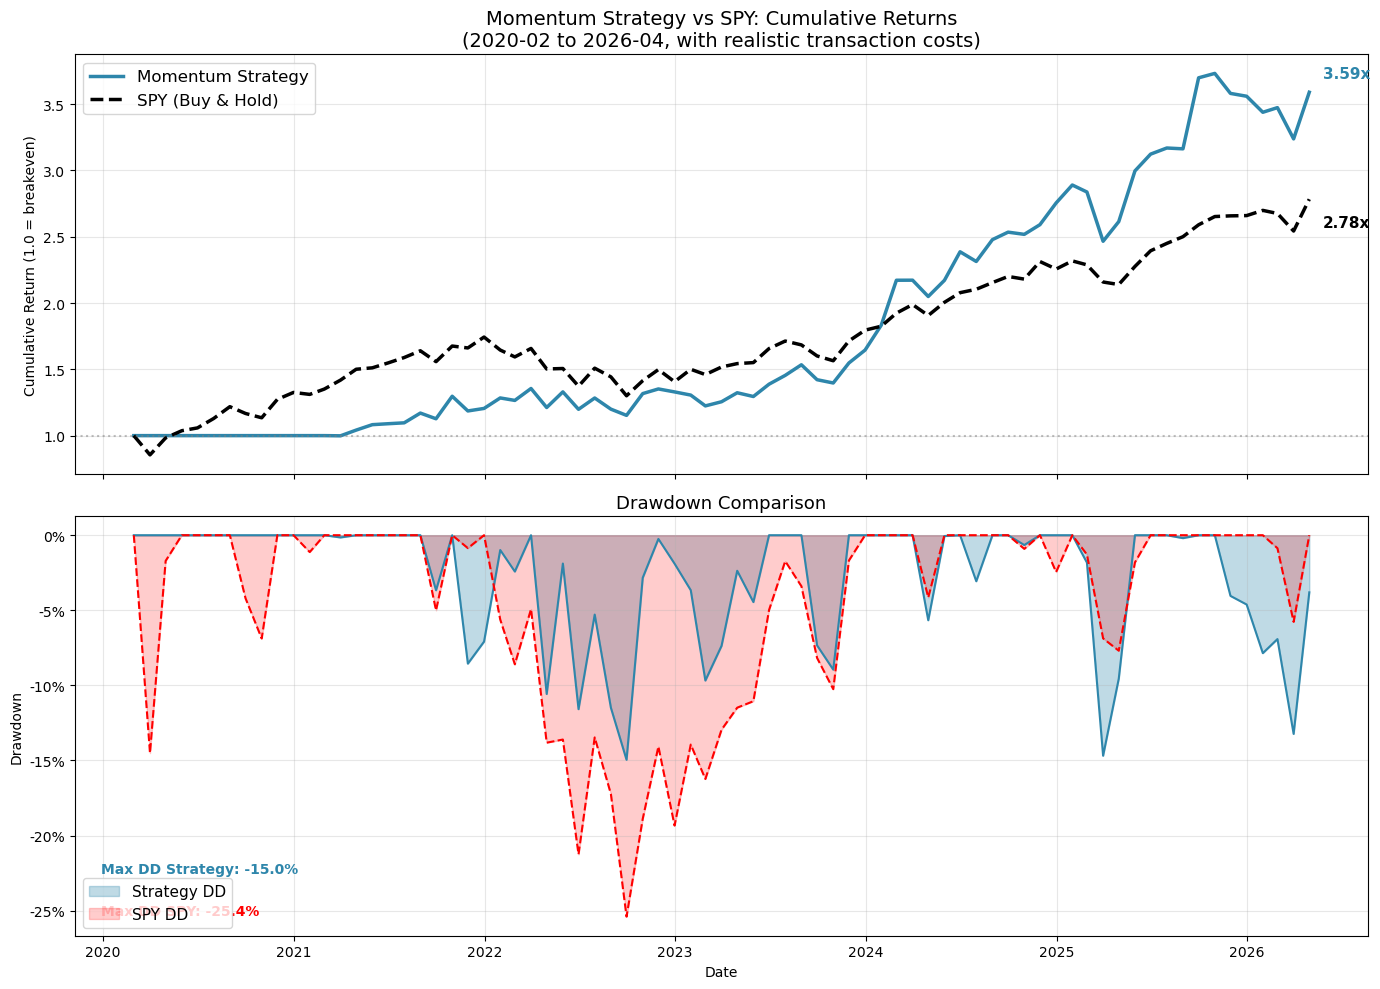

图已保存到: /Users/victor/quant-research-2026/reports/05_backtest_results.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# === 上图：累计收益对比 ===
ax1 = axes[0]
ax1.plot(portfolio_value.index, portfolio_value / INITIAL_CAPITAL, 
         label='Momentum Strategy', color='#2E86AB', linewidth=2.5)
ax1.plot(spy_value.index, spy_value / INITIAL_CAPITAL,
         label='SPY (Buy & Hold)', color='black', linewidth=2.5, linestyle='--')
ax1.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

ax1.set_title('Momentum Strategy vs SPY: Cumulative Returns\n(2020-02 to 2026-04, with realistic transaction costs)', fontsize=14)
ax1.set_ylabel('Cumulative Return (1.0 = breakeven)')
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, alpha=0.3)

# 标注最终数字
final_strat = portfolio_value.iloc[-1] / INITIAL_CAPITAL
final_spy = spy_value.iloc[-1] / INITIAL_CAPITAL
ax1.annotate(f'{final_strat:.2f}x', 
             xy=(portfolio_value.index[-1], final_strat),
             xytext=(10, 10), textcoords='offset points', fontsize=11, color='#2E86AB',
             fontweight='bold')
ax1.annotate(f'{final_spy:.2f}x',
             xy=(spy_value.index[-1], final_spy),
             xytext=(10, -20), textcoords='offset points', fontsize=11, color='black',
             fontweight='bold')

# === 下图：回撤对比 ===
ax2 = axes[1]

# 策略回撤
strat_dd = (portfolio_value - portfolio_value.cummax()) / portfolio_value.cummax()
ax2.fill_between(strat_dd.index, strat_dd, 0, alpha=0.3, color='#2E86AB', label='Strategy DD')
ax2.plot(strat_dd.index, strat_dd, color='#2E86AB', linewidth=1.5)

# SPY 回撤
spy_dd = (spy_value - spy_value.cummax()) / spy_value.cummax()
ax2.fill_between(spy_dd.index, spy_dd, 0, alpha=0.2, color='red', label='SPY DD')
ax2.plot(spy_dd.index, spy_dd, color='red', linewidth=1.5, linestyle='--')

ax2.set_title('Drawdown Comparison', fontsize=13)
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

# 标注最大回撤
max_dd_strat = strat_dd.min()
max_dd_spy = spy_dd.min()
ax2.annotate(f'Max DD Strategy: {max_dd_strat*100:.1f}%', 
             xy=(0.02, 0.15), xycoords='axes fraction',
             fontsize=10, color='#2E86AB', fontweight='bold')
ax2.annotate(f'Max DD SPY: {max_dd_spy*100:.1f}%',
             xy=(0.02, 0.05), xycoords='axes fraction',
             fontsize=10, color='red', fontweight='bold')

plt.tight_layout()

# 保存
output_path = os.path.join(PROJECT_ROOT, 'reports', '05_backtest_results.png')
plt.savefig(output_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"图已保存到: {output_path}")

In [14]:
import json

# 保存完整结果
results_summary = {
    "backtest_date": "2026-05-17",
    "strategy_name": "12-Month Momentum, Top 5, Equal-Weight",
    "parameters": {
        "lookback_months": LOOKBACK_MONTHS,
        "skip_months": SKIP_MONTHS,
        "n_holdings": N_HOLDINGS,
        "rebalance_freq": "monthly",
        "commission": COMMISSION,
        "slippage": SLIPPAGE,
        "initial_capital": INITIAL_CAPITAL
    },
    "period": {
        "start": str(portfolio_value.index[0].date()),
        "end": str(portfolio_value.index[-1].date()),
        "months": len(portfolio_value)
    },
    "metrics": {
        "strategy": {k: float(v) for k, v in strategy_metrics.items()},
        "spy_benchmark": {k: float(v) for k, v in spy_metrics.items()}
    },
    "transaction_costs": {
        "total_cost_usd": float(trades['cost'].sum()),
        "pct_of_initial_capital": float(trades['cost'].sum() / INITIAL_CAPITAL),
        "n_rebalances": len(trades)
    },
    "key_findings": [
        f"Strategy outperformed SPY by 4.90% annualized",
        f"Sharpe Ratio: 0.85 vs SPY 0.75",
        f"Max Drawdown: -15.0% vs SPY -25.4%",
        f"Calmar Ratio 1.52 (2.2x better than SPY)",
        f"Direction: alpha is real after costs, but in-sample only"
    ]
}

with open(os.path.join(PROJECT_ROOT, 'reports', '05_backtest_summary.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✅ 结果已保存到 reports/05_backtest_summary.json")

# 同时保存 portfolio value 时间序列
portfolio_value.to_csv(os.path.join(PROJECT_ROOT, 'reports', '05_portfolio_value.csv'))
spy_value.to_csv(os.path.join(PROJECT_ROOT, 'reports', '05_spy_value.csv'))
print("✅ 价值时序已保存")

✅ 结果已保存到 reports/05_backtest_summary.json
✅ 价值时序已保存
